In [1]:
# Импорты для всего ipynb
from torch.utils.data import DataLoader, random_split

from lab3.logic.config import Paths
from lab3.logic.extraction import run_extraction, ExtractionMethod
from lab3.logic.extraction_visualization import compare_methods_visualize, why_hsv_is_bad_explanation
from lab3.logic.iou import load_source_boxes, evaluate_json_file
from lab3.logic.model import COCODataset, collate_fn, draw_loss_epochs, train
from lab3.logic.result import *

# 1. Извлечение разметки
[_(`extraction.py`)_](./logic/extraction.py)

Для максимально качественного результата и сравнения методов было реализовано 4 различных стратегии "воровства":
1. **Diff (Пространственная разность):** Вычитание оригинального видео из размеченного (`cv2.absdiff`).
2. **HSV (Цветовая фильтрация):** Поиск рамок по одному заданному цвету.
3. **MULTI_HSV:** Поиск по заранее заданному словарю из цветов рамок в `output.mp4`.
4. **YOLOv8:** Попытка найти сами объекты с помощью предобученной нейросети, а не графику.

In [2]:
run_extraction(ExtractionMethod.DIFF, input_video=Paths.SOURCE_INPUT, output_video=Paths.SOURCE_OUTPUT,
               save_frames=True)

run_extraction(ExtractionMethod.HSV, output_video=Paths.SOURCE_OUTPUT)
run_extraction(ExtractionMethod.MULTI_HSV, output_video=Paths.SOURCE_OUTPUT)

run_extraction(ExtractionMethod.YOLO, input_video=Paths.SOURCE_INPUT)

[Diff] Извлечение завершено. Найдено рамок: 2112
[HSV] Извлечение завершено. Найдено рамок: 1300
[MULTI_HSV] Извлечение завершено. Найдено рамок: 4739
[YOLOv8] Извлечение завершено. Найдено рамок: 1837


# 2. Сравнение методов и оценка по IoU
_([`extraction_visualization.py`](./logic/extraction_visualization.py) + [`iou.py`](./logic/iou.py))_

Оценка качества извлечения, путём сравнения извлечённых рамок с эталонной разметкой `annotations.xml` с помощью метрики IoU. Визуализация работы методов на конкретных кадрах.

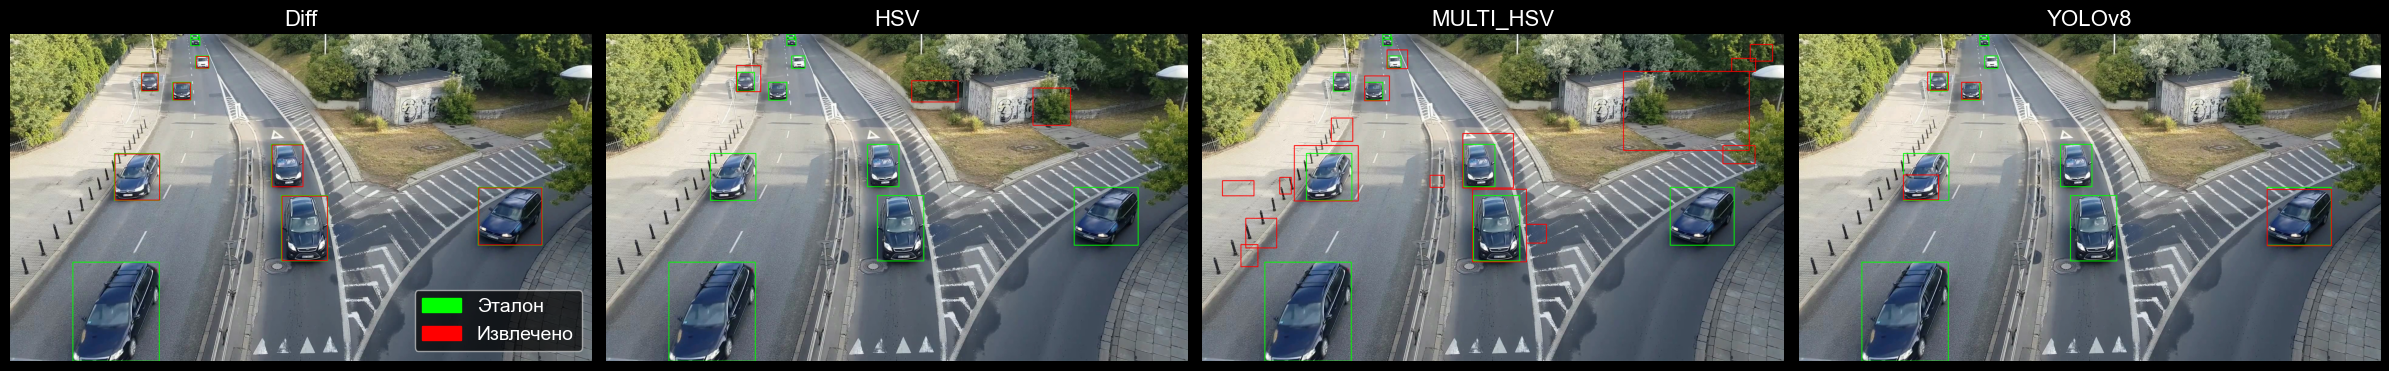

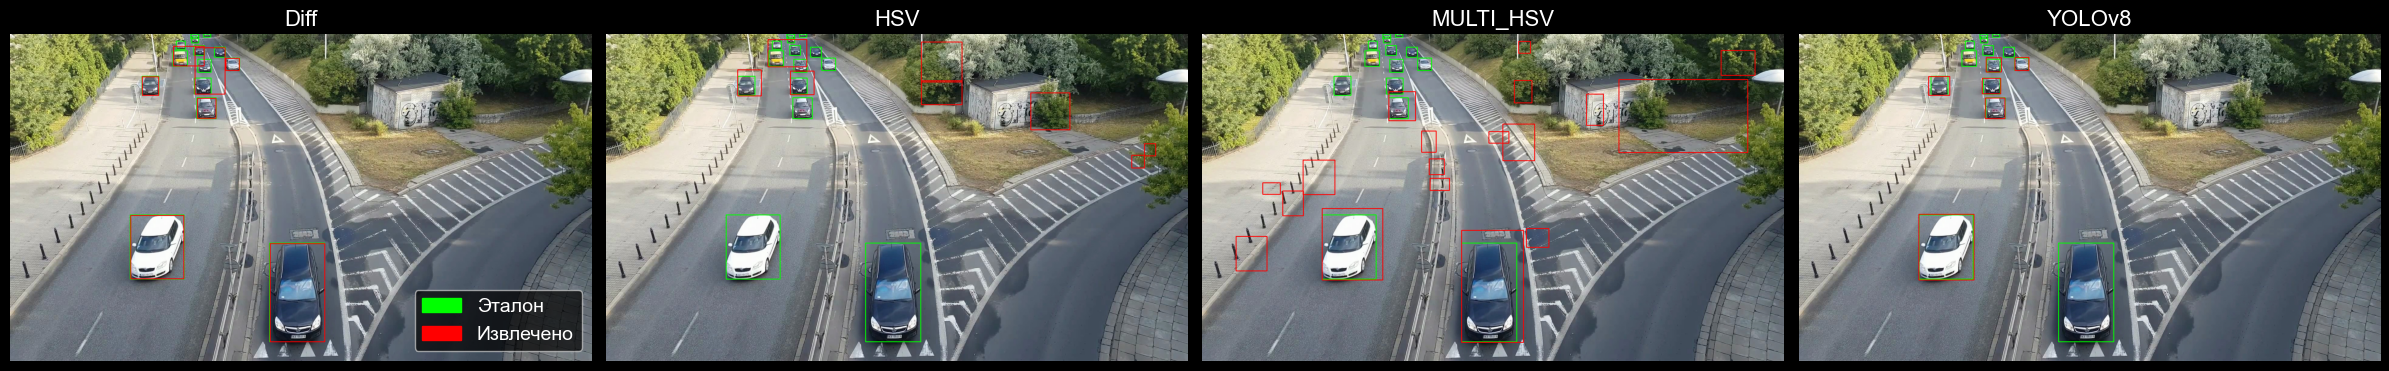

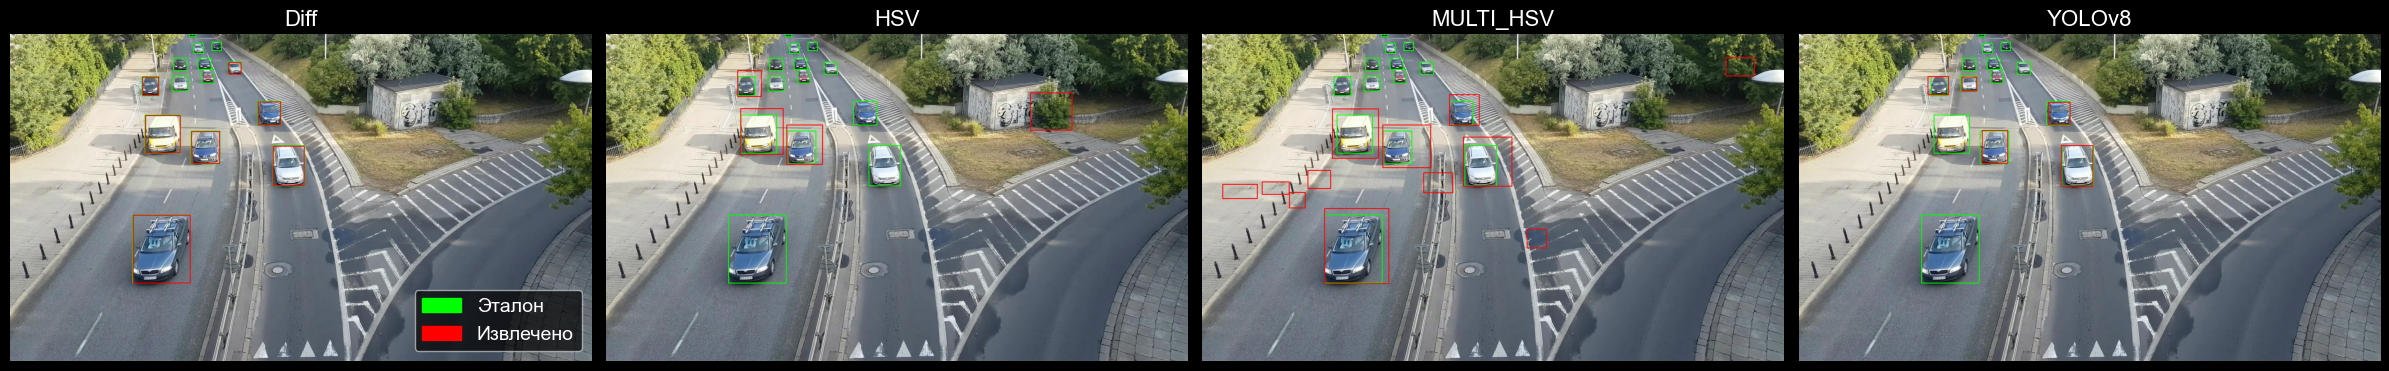


--- Итоговые результаты сравнения методов ---
1. Diff                      -> Средний IoU: 0.8437 (Извлечено рамок: 2112)
2. HSV                       -> Средний IoU: 0.2767 (Извлечено рамок: 1300)
3. MULTI_HSV                 -> Средний IoU: 0.1512 (Извлечено рамок: 4739)
4. YOLOv8                    -> Средний IoU: 0.8390 (Извлечено рамок: 1837)


In [3]:
compare_methods_visualize('frame_0050.jpg')
compare_methods_visualize('frame_0150.jpg')
compare_methods_visualize('frame_0250.jpg')

print(f"\n--- Итоговые результаты сравнения методов ---")
source_data = load_source_boxes(Paths.SOURCE_ANNOTATIONS)
for i, method in enumerate(ExtractionMethod, start=1):
    mean_iou, count = evaluate_json_file(method.path, source_data)
    print(f"{i}. {method.label:<25} -> Средний IoU: {mean_iou:.4f} (Извлечено рамок: {count})")


**Анализ результатов:**
* **Diff:** Показал наивысшую точность (IoU > 0.84). Главный недостаток – требует наличия чистого исходника (`input.mp4`). **Именно этот метод выбран для создания итогового датасета.**
* **YOLOv8:** Показал отличный результат (IoU ~0.84). Предобученная модель неплохо находит автомобили, и её видение границ объектов совпало с разметкой человека. Однако этот метод не ворует *графику*, он делает разметку заново.
* **HSV / MULTI_HSV:** Методы цветовой фильтрации показали низкий IoU. И вот почему... _(см. ячейку ниже)_

> У Diff для максимизации IoU использовались приёмы, которые игнорировали "мусор" (например, рамки рядом с краем – они детектились плохо(((

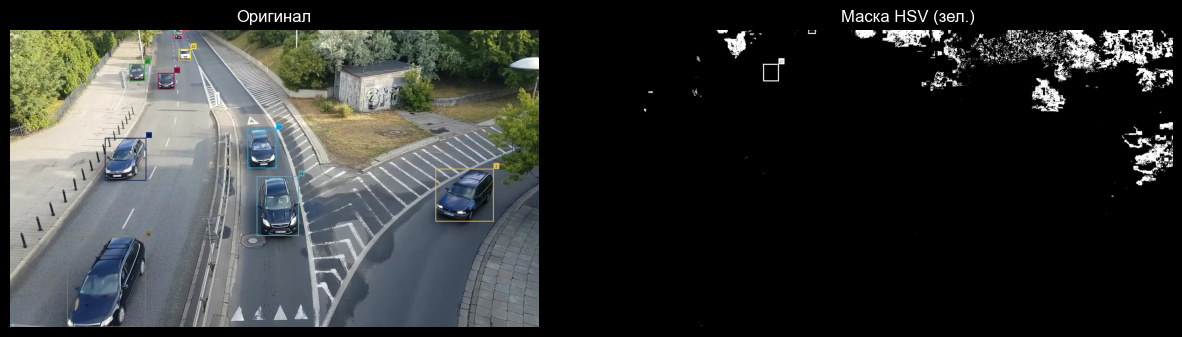

In [4]:
why_hsv_is_bad_explanation(50)

Выше показана маска HSV для зелёных рамок – можно заметить, что зелёные у нас не только рамки (но и деревья) – они создают шумы.

Для HSV с множеством цветов эта проблема проявляется ещё сильнее, т.к. даже на примере рамка слева-снизу сливается с дорогой. (+деревья, +машины разных цветов -> всё оч плохо)

Можно попробовать улучшить данный результат, например, выделив область дороги – чтобы маска не триггерилась на деревья, но это всё ещё не решит нашу проблему =(

# 3. Подготовка датасета и обучение модели (Faster R-CNN)
[_(`model.py`)_](./logic/model.py)

На основе лучшей извлеченной разметки (метод Diff) формируем COCO-датасет. Выборка разбивается на обучающую и валидационную в пропорции 80/20.

В качестве архитектуры выбрана **Faster R-CNN** (`fasterrcnn_resnet50_fpn`).

**Контроль переобучения:**
Для предотвращения переобучения реализован механизм **Early Stopping** (с параметром `patience=3`). В конце каждой эпохи модель оценивается на валидационном наборе данных без обновления весов (`torch.no_grad()`). Сохранение лучших весов (`best_model.pth`) происходит строго при падении Validation Loss, а не Train Loss.

In [5]:
dataset = COCODataset(Paths.IMAGES_DIR, ExtractionMethod.DIFF.path)

torch.manual_seed(42)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

Обучение запущено на устройстве: cpu
Epoch 01 | Train Loss: 0.4549 | Val Loss: 0.2901
Epoch 02 | Train Loss: 0.2382 | Val Loss: 0.2448
Epoch 03 | Train Loss: 0.2037 | Val Loss: 0.2305
Epoch 04 | Train Loss: 0.1740 | Val Loss: 0.2006
Epoch 05 | Train Loss: 0.1449 | Val Loss: 0.1943
Epoch 06 | Train Loss: 0.1258 | Val Loss: 0.2048
Epoch 07 | Train Loss: 0.1162 | Val Loss: 0.2179
Epoch 08 | Train Loss: 0.1100 | Val Loss: 0.1845
Epoch 09 | Train Loss: 0.0966 | Val Loss: 0.2155
Epoch 10 | Train Loss: 0.0906 | Val Loss: 0.1957


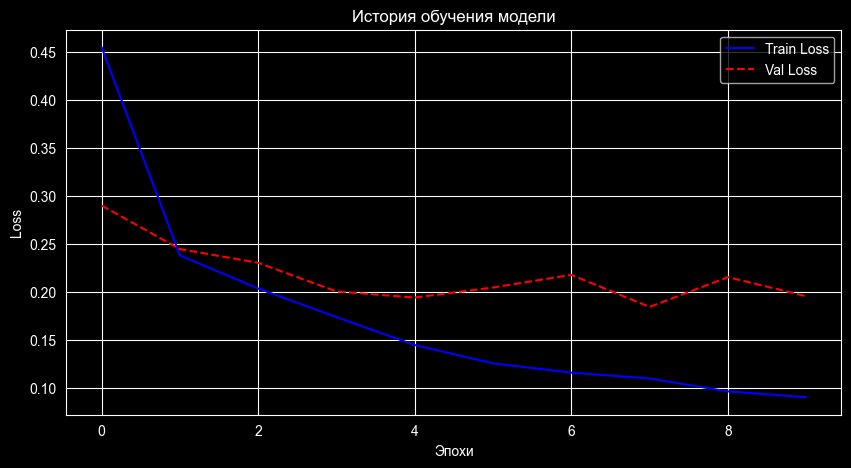

In [6]:
model, device, train_losses, val_losses = train(
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=10,
    patience=3
)

draw_loss_epochs(train_losses, val_losses)

# 4. Оценка качества (mAP) и анализ результатов
[_(`result.py`)_](./logic/result.py)


Расчет метрик на val...
mAP @ [IoU=0.50:0.95]: 0.8561
mAP @ [IoU=0.50]:      0.9586


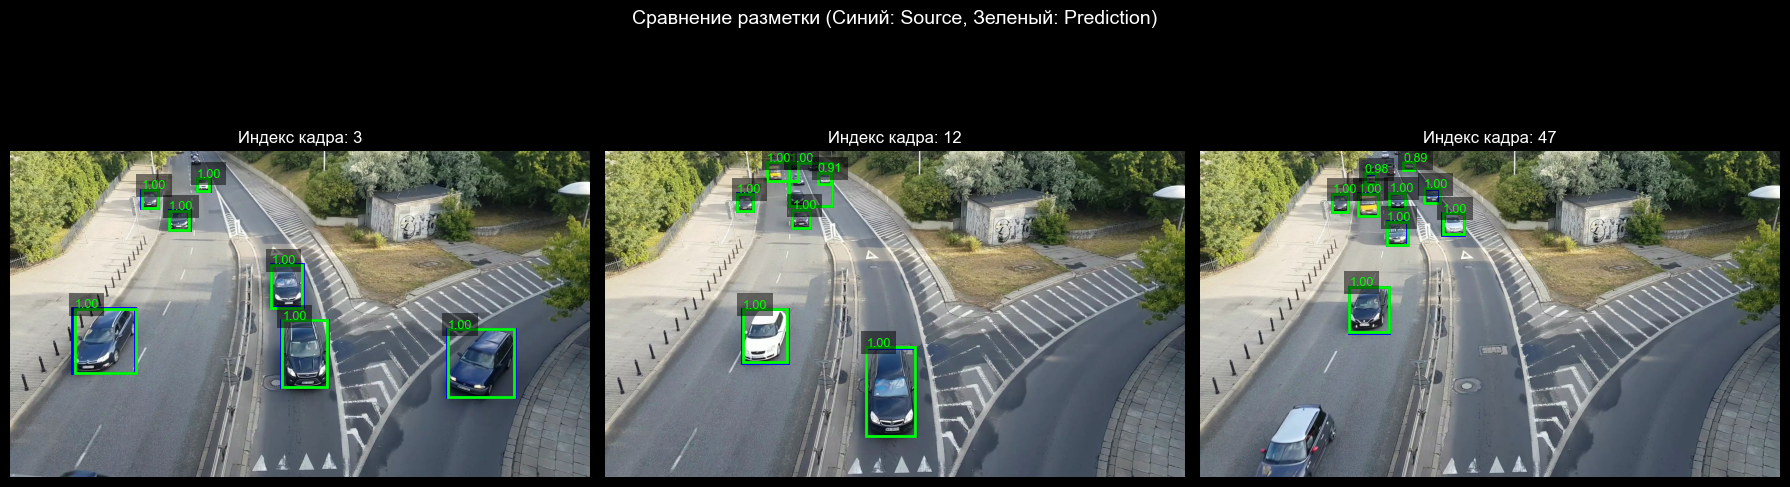

In [7]:
model.load_state_dict(torch.load(Paths.BEST_MODEL_DIST, map_location=device))
model.eval()

count_map(model=model, device=device, val_loader=val_loader)

plot_predictions_row([3, 12, 47], val_dataset, model, device)

**Анализ результатов:**
* **Детектируется ХОРОШО:** Модель уверенно находит крупные и средние автомобили по центру дороги.
* **Детектируется ПЛОХО:** Наблюдаются проблемы с автомобилями на дальнем плане. Также модель иногда испытывает трудности, когда машины перекрывают друг друга (обычно вдали). +Машины, которые не полностью видно, очень часто не учитываются (см. 3 рисунок)

In [8]:
make_predicted_video(Paths.SOURCE_INPUT, Paths.RESULT_VIDEO_DIST, model, device)

Видео создаётся...
Видео сохранено в файл: output/result.mp4
